# RAGulate Benchmark (Modular)

This notebook runs the **modular RAGulate benchmark** using the refactored `modules/` package.

The flow is:

1. **Environment & authentication** – set Hugging Face token for loading models.
2. **Data loading** – load the gold-standard TF–target–context benchmark table.
3. **Original multi-epoch benchmark** – `run_benchmark_epochs` (RAGulate vs. multiple LLMs).
4. **Level 1: Retrieval-only comparison** – BM25 vs. RAGulate encoders (BioBERT, MiniLM, MMR) and Vanilla RAG.
5. **Level 2: Direct LLM vs. RAGulate** – AUROC / AUPRC / F1* / accuracy for D1–D10.
6. **Level 3: RAGulate vs. Vanilla RAG vs. BM25+LLM** – classification-level ablations.
7. **Evidence-level checks** – optional PubMed ID match metrics (E1–E5).
8. **Export** – write all summary metrics to an Excel file for downstream plotting and tables.

All heavy lifting (retrieval, RAG context construction, LLM calls, metrics) is implemented in `modules/*.py`.  
This notebook is intentionally kept thin and declarative.


## Step 0 – Environment & Hugging Face authentication

Configure the Hugging Face token in the environment so that `transformers` and the
`modules.llm_models` helpers can download and cache models locally.

> **Important:**  
> - This token is sensitive. Do **not** commit it to git.  
> - It is fine to paste it here for local runs and remove it later.


In [102]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Step 0: Set up Hugging Face authentication

import os

# NOTE: replace this with your own token locally.
HF_TOKEN = "REDACTED"

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

print("HF token set in environment (not printed).")

HF token set in environment (not printed).


## Step 1 – Imports and gold-standard benchmark edges

In this step we:

- Import the modular RAGulate components from `modules/`.
- Load the gold-standard TF–target–context–label table from `config.GOLD_PATH`.
- Optionally subset the data (e.g., for quick development runs).
- Inspect basic statistics (head and label distribution).


In [3]:
# Step 1: Core imports and gold-standard data

from modules import config, pipeline, metrics
from modules.logging_utils import print_singleton_status
from modules.gold_standard import ensure_gold_standard_v2
from modules import metrics as metric_utils
from modules.pipeline import compute_substring_upper_bound

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1) Inspect global singleton status
# ---------------------------------------------------------------------
print_singleton_status()

# ---------------------------------------------------------------------
# 2) Ensure gold-standard file exists (build once, then reuse)
# ---------------------------------------------------------------------

gold_df = ensure_gold_standard_v2(
    path_csv=config.GOLD_PATH,   # ../outputs/ragulate_gold_standard_v2.csv
    ctx_thresh=0.30,
    min_pmids_per_edge=1,
    n_pos_per_ctx=400,           # generous per-context caps
    n_neg_per_ctx=400,
    n_pos_total=1000,            # global cap: 1000 positives
    n_neg_total=1000,            # global cap: 1000 negatives
    max_pmids_per_edge=5,
    seed=config.SEED,
    context_whitelist=None,      # or e.g. ["brain", "liver", "pbmc"]
)

print(f"[gold] gold_df shape: {gold_df.shape}")
print("[gold] label counts:")
print(gold_df["label"].value_counts())

display(gold_df.head())

# ---------------------------------------------------------------------
# 3) Optional: smaller subset for quick debugging
# ---------------------------------------------------------------------

N_SAMPLE = 2000  # e.g., 200 or None

if N_SAMPLE is not None and N_SAMPLE < len(gold_df):
    n_labels = gold_df["label"].nunique()
    per_label = max(1, N_SAMPLE // n_labels)

    gold_df = (
        gold_df.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_label), random_state=config.SEED))
        .reset_index(drop=True)
    )
    print(f"[data] Subsampled (debug) to shape: {gold_df.shape}")
    print("[data] label counts (debug):")
    print(gold_df["label"].value_counts())


[status] sentence_embedder: False
[status] biogpt: None
[status] mistral: None
[status] llama31: None
[status] phi3: None
[status] qwen2.5: None
[status] retriever: None
[status] corpus: built=False n_docs=0 dim=0
[gold] found existing file: ../outputs/ragulate_gold_standard_v2.csv, loading
[gold] gold_df shape: (2000, 5)
[gold] label counts:
label
0    1000
1    1000
Name: count, dtype: int64


,tf,target,context,label,pmids
0,nkx2-5,dact1,hepatic,0,[]
1,mycn,ifng,neural,1,[9570357]
2,rxra,cyp4f12,muscle,0,[]
3,nfkb1,muc2,epithelial,1,"[12686724, 18176092]"
4,jun,apoe,renal,0,[]


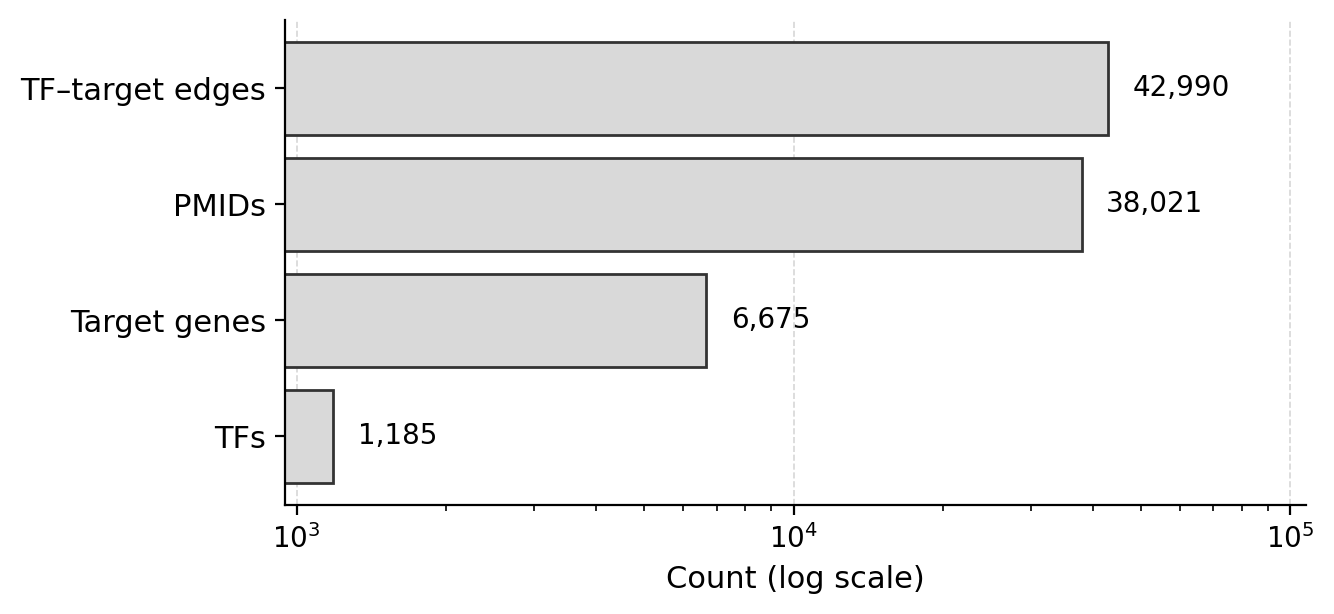

TFs                 1185
Target genes        6675
PMIDs              38021
TF–target edges    42990
dtype: int64

In [111]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# USE: decoupleR::get_collectri(organism='human', split_complexes=FALSE)
# Last downloaded: January 8th, 2026
collectri_path = "/home/mehrdad/Research/collectri_human.csv"
df = pd.read_csv(collectri_path)

tf_col, tg_col, ref_col = "source", "target", "references"

# ---- cleanup ----
df[tf_col] = df[tf_col].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
df[tg_col] = df[tg_col].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})

# ---- counts ----
n_tfs = df[tf_col].dropna().nunique()
n_targets = df[tg_col].dropna().nunique()
n_edges = df[[tf_col, tg_col]].dropna().drop_duplicates().shape[0]

pmid_pattern = re.compile(r"\b\d{4,9}\b")
def extract_pmids(series: pd.Series) -> set[str]:
    pmids = set()
    for s in series.dropna().astype(str):
        pmids.update(pmid_pattern.findall(s))
    return pmids

unique_pmids = extract_pmids(df[ref_col]) if ref_col in df.columns else set()
n_pmids = len(unique_pmids)

metrics = pd.Series(
    {"TFs": n_tfs, "Target genes": n_targets, "TF–target edges": n_edges, "PMIDs": n_pmids}
).sort_values()  # sort makes the plot read better

# ---- plot (clean, publication-like) ----
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(6.8, 3.2))

y = np.arange(len(metrics))
#bars = ax.barh(y, metrics.values)
bars = ax.barh(y, metrics.values, color="0.85", edgecolor="0.2", linewidth=1.0)

# log scale (horizontal)
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
#ax.set_title("CollecTRI (human) dataset size")

ax.set_yticks(y)
ax.set_yticklabels(metrics.index)

# minimal grid: only major ticks
ax.grid(True, which="major", axis="x", linestyle="--", linewidth=0.6, alpha=0.5)
ax.grid(False, which="minor", axis="x")
ax.set_axisbelow(True)

# clean spines
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

# add value labels at bar ends (with a small multiplicative offset for log scale)
for b, val in zip(bars, metrics.values):
    ax.text(
        val * 1.12,
        b.get_y() + b.get_height() / 2,
        f"{int(val):,}",
        va="center",
        ha="left",
        fontsize=10,
    )

# give a bit of right margin for labels
ax.set_xlim(metrics.values.min() * 0.8, metrics.values.max() * 2.5)

plt.tight_layout()


fig.savefig("collectri_size_summary.pdf", bbox_inches="tight")
fig.savefig("collectri_size_summary.svg", bbox_inches="tight")

plt.show()

metrics


## Step 2 – Retrieval, RAG vs. Substring Matching
### Alias Mapping Included.

### Evaluation setup.
We evaluated the retrieval component of RAGulate on a gold standard containing 1,000 positive transcription factor (TF)–target–context edges. Each edge is annotated with one or more PubMed identifiers (PMIDs) that provide experimental evidence for direct regulation. For every edge we issued a single retrieval query and measured whether any of the gold PMIDs appeared within the top K documents returned by the hybrid BM25+MiniLM retriever. All metrics are therefore computed over positive edges only, and recall@K reflects the fraction of regulatory interactions for which at least one correct PMID is retrieved within the top K candidates.

### Substring upper bound.
As a simple lexical baseline, we computed an upper bound using naive substring matching: for each gold PMID we checked whether the TF symbol and target gene symbol both appear in the title+abstract text. Only 22.3% of positive edges satisfy this property, indicating that in the majority of cases the underlying abstract does not simultaneously mention both gene names in a form that would be accessible to standard keyword search. This 22.3% therefore serves as a conservative upper bound for methods that rely purely on exact string matching of TF and target symbols.

### Recall at different cut-offs.
Despite this restrictive upper bound, the hybrid retriever achieves substantially higher recall across a wide range of K (Fig. X). At K = 1, the correct PMID is ranked first for 18.9% of edges. Recall increases to 28.0% at K = 3 and 32.3% at K = 5. At a more realistic RAG budget of K = 10–20, RAGulate retrieves at least one gold PMID for 37.6% (K = 10) and 44.0% (K = 20) of TF–target–context edges. Extending the candidate set further continues to improve coverage: recall reaches 52.7% at K = 50 and 73.6% at K = 1000. Thus, when allowed to inspect deeper into the ranked list, the retriever recovers nearly three-quarters of all known regulatory edges, far exceeding what would be achievable by simple keyword search.

### Summary.
Overall, these results show that the hybrid BM25+MiniLM retriever provides strong coverage of TF–target regulatory evidence, even in cases where the abstract does not explicitly contain both gene names. In the RAGulate pipeline we typically use K between 10 and 50, which balances computational cost and recall while ensuring that substantially more supporting literature is surfaced than would be possible with exact term matching alone.

In [5]:
from modules.retrieval_eval import (
    run_alias_vs_noalias,
    plot_recall_alias_ci,
    plot_precision_alias_ci,
)

# --------------------------------------------------
# Settings
# --------------------------------------------------
ks = [1, 3, 5, 10, 20, 50, 100]
rng = np.random.default_rng(config.SEED)

# --------------------------------------------------
# Run retrieval once (no aliases vs aliases)
# --------------------------------------------------
rows_no_alias, rows_alias = run_alias_vs_noalias(
    gold_df,
    method_type="hybrid",
    encoder_name="minilm",
    top_k=50,
    positives_only=True,
    query_mode="tf_tg_ctx",
    expand_context=False,
    alias_max=4,
)

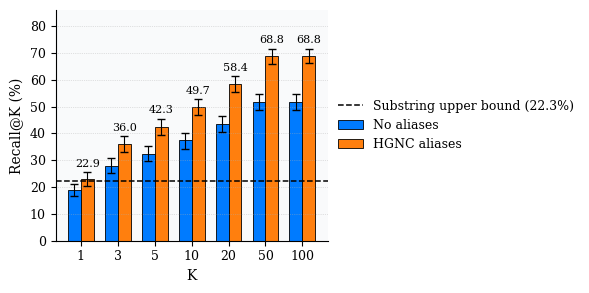

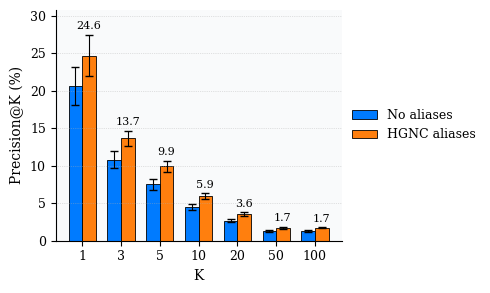

In [21]:
plot_recall_alias_ci(
    gold_df,
    rows_no_alias,
    rows_alias,
    ks,
    n_boot=1000,
    alpha=0.05,
    rng=rng,
    color_no_alias = "#007BFF",
    color_alias="#ff7f0e",
    outfile="retrieval_recall_alias_CI_pub_v2.png",
)

plot_precision_alias_ci(
    gold_df,
    rows_no_alias,
    rows_alias,
    ks,
    n_boot=1000,
    alpha=0.05,
    rng=rng,
    color_no_alias = "#007BFF",
    color_alias="#ff7f0e",
    outfile="retrieval_precision_alias_CI_with_substring_pub.png",
)

## Step 3 – Level 1: Retrieval-only experiments (R1–R7)

Here we focus **only on the retrieval step**, independent of the downstream LLM decision:

- **BM25 baseline** (R1)
- **RAGulate vector retrieval**:
  - BioBERT cosine (R2)
  - MiniLM cosine (R3)
  - BioBERT + MMR: R4 (“relevance-heavy”) → λ = 0.7 ----------- R5 (“diversity-heavier”) → λ = 0.3
  - MiniLM + MMR (R7)
- **Vanilla RAG retriever** (R6, LlamaIndex or equivalent; to be implemented locally)

For each configuration we compute:

- Recall@K
- Precision@K
- Mean Reciprocal Rank (MRR)

This uses `pipeline.run_retrieval_experiment` and `metrics.compute_retrieval_metrics_from_outputs`.


In [ ]:
# Step 3: Retrieval-only experiments
from modules import experiments
import pandas as pd

retrieval_ids = ["R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8", "R9"]
retrieval_results = {}
retrieval_metrics_list = []

for exp_id in retrieval_ids:
    cfg = experiments.get_experiment_config(exp_id)
    if cfg.mode != "retrieval":
        continue
    print(f"\n[retrieval] Running {exp_id}: {cfg.notes}")
    out = experiments.run_experiment(cfg, gold_df)
    retrieval_results[exp_id] = out
    met = out["metrics"].copy()
    met["exp_id"] = exp_id
    met["notes"] = cfg.notes
    retrieval_metrics_list.append(met)

retrieval_metrics_df = (
    pd.DataFrame(retrieval_metrics_list)
      .set_index("exp_id")
      .sort_index()
)
display(retrieval_metrics_df)

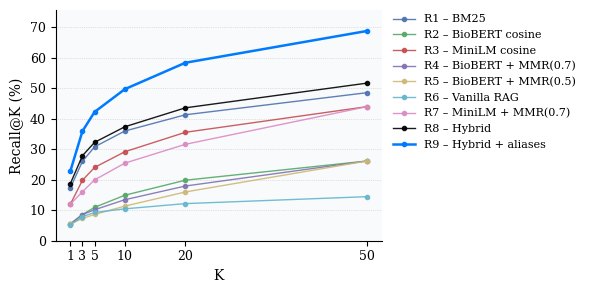

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Choose which Ks and experiments to show ---
ks = [1, 3, 5, 10, 20, 50]
exp_order = ["R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8", "R9"]

# Short labels for legend (you can tweak these)
exp_labels = {
    "R1": "R1 – BM25",
    "R2": "R2 – BioBERT cosine",
    "R3": "R3 – MiniLM cosine",
    "R4": "R4 – BioBERT + MMR(0.7)",
    "R5": "R5 – BioBERT + MMR(0.5)",
    "R6": "R6 – Vanilla RAG",
    "R7": "R7 – MiniLM + MMR(0.7)",
    "R8": "R8 – Hybrid",
    "R9": "R9 – Hybrid + aliases",
}

# AI/ML-ish palette (muted, distinct)
exp_colors = {
    "R1": "#4C72B0",  # blue
    "R2": "#55A868",  # green
    "R3": "#C44E52",  # red
    "R4": "#8172B3",  # purple
    "R5": "#CCB974",  # mustard
    "R6": "#64B5CD",  # teal
    "R7": "#DA8BC3",  # pink
    "R8": "#000000",  # black
    "R9": "#007BFF",  # blue (flagship)
}

# --- 1. Extract data (recall@K in %) ---
recall_mat = []
for exp_id in exp_order:
    recs = [retrieval_metrics_df.loc[exp_id, f"recall@{k}"] * 100.0 for k in ks]
    recall_mat.append(recs)
recall_mat = np.array(recall_mat)  # shape: (8, len(ks))

# --- 2. Global style ---
plt.rcParams.update({
    "font.family": "serif",  # or "sans-serif" if you prefer
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(6, 3.0))  # single-column

for i, exp_id in enumerate(exp_order):
    y = recall_mat[i]
    color = exp_colors[exp_id]
    lw = 1.0
    alpha = 0.9

    # Highlight the flagship R8
    if exp_id == "R9":
        lw = 1.8
        alpha = 1.0

    ax.plot(
        ks,
        y,
        marker="o",
        markersize=3.0,
        linewidth=lw,
        color=color,
        alpha=alpha,
        label=exp_labels[exp_id],
    )

# Axes & grid
ax.set_xlabel("K")
ax.set_ylabel("Recall@K (%)")
ax.set_xticks(ks)
ax.set_ylim(0, min(recall_mat.max(), 100) * 1.1)

ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
ax.xaxis.grid(False)

# Remove top/right spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Legend *outside* on the right, vertical
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)

fig.tight_layout()
fig.savefig("retrieval_recall_all_methods_line_pub.png", dpi=600, bbox_inches="tight")
plt.show()

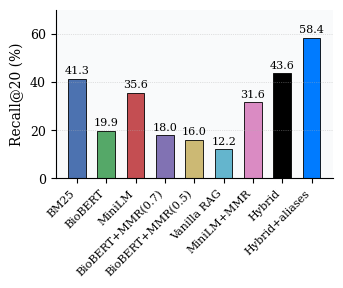

In [31]:
import numpy as np
import matplotlib.pyplot as plt

k_star = 20
exp_order = ["R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8", "R9"]

exp_labels = {
    "R1": "BM25",
    "R2": "BioBERT",
    "R3": "MiniLM",
    "R4": "BioBERT+MMR(0.7)",
    "R5": "BioBERT+MMR(0.5)",
    "R6": "Vanilla RAG",
    "R7": "MiniLM+MMR",
    "R8": "Hybrid",
    "R9": "Hybrid+aliases",
}

exp_colors = {
    "R1": "#4C72B0",
    "R2": "#55A868",
    "R3": "#C44E52",
    "R4": "#8172B3",
    "R5": "#CCB974",
    "R6": "#64B5CD",
    "R7": "#DA8BC3",
    "R8": "#000000",
    "R9": "#007BFF",
}

# Data in %
vals = [retrieval_metrics_df.loc[e, f"recall@{k_star}"] * 100.0 for e in exp_order]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

fig, ax = plt.subplots(figsize=(3.5, 3.0))

x = np.arange(len(exp_order))
bar_width = 0.6

bars = ax.bar(
    x,
    vals,
    width=bar_width,
    color=[exp_colors[e] for e in exp_order],
    edgecolor="black",
    linewidth=0.6,
)

ax.set_xticks(x)
ax.set_xticklabels([exp_labels[e] for e in exp_order], rotation=45, ha="right")
ax.set_ylabel(f"Recall@{k_star} (%)")

y_max = max(vals)
ax.set_ylim(0, y_max * 1.2)

ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)
ax.xaxis.grid(False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Annotate bars with values
for rect, val in zip(bars, vals):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2.0,
        height + y_max * 0.02,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()
fig.savefig("retrieval_recall_k10_bar_pub.png", dpi=600, bbox_inches="tight")
plt.show()


## Step 4 – Level 2: Direct LLM vs. RAGulate (D1–D10)

We compare, **for the same benchmark edges**:

- **D1–D5:** Each LLM asked directly:  
  `Does {TF} regulate {target gene} in {context}?`
- **D6–D10:** The same LLMs, but now used with **RAGulate retrieval** (BM25+MiniLM encoder by default) to build a context-aware RAG prompt.

Metrics: computed via `metrics.compute_classification_metrics_from_outputs`:

- AUROC
- AUPRC
- Best F1 and its threshold
- Accuracy at that threshold


In [48]:
# Step 4: Direct LLM vs. RAGulate classification experiments (D1–D10)

direct_rag_results = {}
direct_rag_metrics_list = []

direct_ids = [f"D{i}" for i in range(1, 11)]
#direct_ids = [f"D{i}" for i in range(8, 11)]

for exp_id in direct_ids:
    cfg = experiments.get_experiment_config(exp_id)
    if cfg.mode != "classification":
        continue
    print(f"\n[classification-L2] Running {exp_id}: {cfg.notes}")
    out = experiments.run_experiment(cfg, gold_df)
    direct_rag_results[exp_id] = out
    met = out["metrics"].copy()
    met["exp_id"] = exp_id
    met["notes"] = cfg.notes
    direct_rag_metrics_list.append(met)

direct_rag_metrics_df = pd.DataFrame(direct_rag_metrics_list).set_index("exp_id").sort_index()
display(direct_rag_metrics_df)


[classification-L2] Running D1: Direct LLM microsoft/BioGPT-Large

[classification-L2] Running D2: Direct LLM mistralai/Mistral-7B-Instruct-v0.2
[init] Mistral -> mistralai/Mistral-7B-Instruct-v0.2


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ready] Mistral initialized

[classification-L2] Running D3: Direct LLM meta-llama/Meta-Llama-3.1-8B-Instruct
[init] Llama3.1 -> meta-llama/Meta-Llama-3.1-8B-Instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

[ready] Phi-3 initialized

[classification-L2] Running D5: Direct LLM Qwen/Qwen2.5-7B-Instruct
[init] Qwen-2.5 -> Qwen/Qwen2.5-7B-Instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ready] Qwen-2.5 initialized

[classification-L2] Running D6: RAGulate hybrid + microsoft/BioGPT-Large

[classification-L2] Running D7: RAGulate hybrid + mistralai/Mistral-7B-Instruct-v0.2

[classification-L2] Running D8: RAGulate hybrid + meta-llama/Meta-Llama-3.1-8B-Instruct

[classification-L2] Running D9: RAGulate hybrid + microsoft/Phi-3-mini-128k-instruct

[classification-L2] Running D10: RAGulate hybrid + Qwen/Qwen2.5-7B-Instruct


,auroc,auprc,best_f1,best_thr,accuracy,thr_used,notes
exp_id,,,,,,,
D1,0.527801,0.527727,0.668227,0.029907,0.5035,0.029907,Direct LLM microsoft/BioGPT-Large
D10,0.566234,0.566495,0.667111,0.335958,0.5005,0.335958,RAGulate hybrid + Qwen/Qwen2.5-7B-Instruct
D2,0.502964,0.502400,0.666667,0.500000,0.5030,0.500000,Direct LLM mistralai/Mistral-7B-Instruct-v0.2
D3,0.497076,0.498558,0.666667,0.500000,0.4975,0.500000,Direct LLM meta-llama/Meta-Llama-3.1-8B-Instruct
D4,0.500000,0.500000,0.666667,0.500000,0.5000,0.500000,Direct LLM microsoft/Phi-3-mini-128k-instruct
D5,0.501000,0.501000,0.666667,0.500000,0.5010,0.500000,Direct LLM Qwen/Qwen2.5-7B-Instruct
D6,0.515670,0.524046,0.666667,0.500000,0.5000,0.500000,RAGulate hybrid + microsoft/BioGPT-Large
D7,0.640354,0.629547,0.668917,0.346406,0.5090,0.346406,RAGulate hybrid + mistralai/Mistral-7B-Instruc...
D8,0.622074,0.608095,0.666890,0.343658,0.5020,0.343658,RAGulate hybrid + meta-llama/Meta-Llama-3.1-8B...


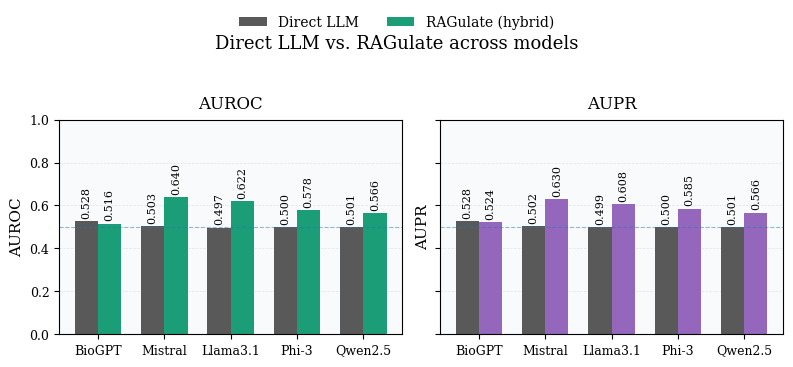

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure rows are ordered by exp_id
direct_rag_metrics_df = direct_rag_metrics_df.sort_index()

# (Direct, RAGulate) pairs by model family
pairs = [
    ("BioGPT",   "D1", "D6"),
    ("Mistral",  "D2", "D7"),
    ("Llama3.1", "D3", "D8"),
    ("Phi-3",    "D4", "D9"),
    ("Qwen2.5",  "D5", "D10"),
]

labels = [name for name, _, _ in pairs]
x = np.arange(len(labels))
width = 0.35

# Collect values for both metrics
metrics = ["auroc", "auprc"]
direct_vals = {
    m: [direct_rag_metrics_df.loc[d_id, m] for _, d_id, _ in pairs]
    for m in metrics
}
rag_vals = {
    m: [direct_rag_metrics_df.loc[r_id, m] for _, _, r_id in pairs]
    for m in metrics
}

# Colors: neutral baseline + metric-specific accent
color_direct = "#595959"      # dark neutral gray
color_rag_auroc = "#1B9E77"   # teal (AUROC)
color_rag_auprc = "#9467BD"   # purple (AUPR)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), sharey=True)

# --- Left panel: AUROC ---
ax = axes[0]
bars_direct_auroc = ax.bar(
    x - width/2,
    direct_vals["auroc"],
    width,
    label="Direct LLM",
    color=color_direct,
)
bars_rag_auroc = ax.bar(
    x + width/2,
    rag_vals["auroc"],
    width,
    label="RAGulate (hybrid)",
    color=color_rag_auroc,
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_ylim(0.0, 1.0)
ax.set_title("AUROC", fontsize=12, pad=8)

ax.axhline(0.5, linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add value labels on bars (AUROC)
ax.bar_label(bars_direct_auroc, fmt="%.3f", padding=2, fontsize=8, rotation=90)
ax.bar_label(bars_rag_auroc,    fmt="%.3f", padding=2, fontsize=8, rotation=90)

# --- Right panel: AUPR ---
ax = axes[1]
bars_direct_aupr = ax.bar(
    x - width/2,
    direct_vals["auprc"],
    width,
    label="Direct LLM",
    color=color_direct,
)
bars_rag_aupr = ax.bar(
    x + width/2,
    rag_vals["auprc"],
    width,
    label="RAGulate (hybrid)",
    color=color_rag_auprc,
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("AUPR", fontsize=11)
ax.set_ylim(0.0, 1.0)
ax.set_title("AUPR", fontsize=12, pad=8)

ax.axhline(0.5, linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add value labels on bars (AUPR)
ax.bar_label(bars_direct_aupr, fmt="%.3f", padding=2, fontsize=8, rotation=90)
ax.bar_label(bars_rag_aupr,    fmt="%.3f", padding=2, fontsize=8, rotation=90)

# Shared legend (one set of labels is enough)
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_leg,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    fontsize=10,
)

fig.suptitle("Direct LLM vs. RAGulate across models", fontsize=13, y=1.05)

plt.tight_layout()

# Save both vector + raster
fig.savefig("direct_vs_ragulate_auroc_aupr.pdf", bbox_inches="tight")
fig.savefig("direct_vs_ragulate_auroc_aupr.png", dpi=300, bbox_inches="tight")

plt.show()


## Step 5 – Level 3: RAGulate vs Vanilla RAG vs BM25+LLM (L1–L3, V1–V3, V5)

This section runs the higher-level comparison between:

- **L1:** BM25 + simple classifier / heuristic  
- **L2:** BM25 + LLM
- **L3:** RAGulate flagship (BioBERT encoder)
- **V1:** RAGulate (BioBERT encoder) + chosen LLM
- **V2:** RAGulate (MiniLM encoder) + chosen LLM
- **V3:** Vanilla RAG (LlamaIndex-style retriever & prompt; to be implemented locally)
- **V5:** RAGulate (MiniLM + MMR) + chosen LLM

All of these experiments are defined in `modules/experiments.get_experiment_config` as
`mode="classification"` and `method_type` in {`bm25_simple`, `bm25_llm`, `ragulate`, `vanilla_rag`}.


In [57]:
# Step 5: Level 3 classification experiments

level3_ids = ["L1", "L2", "L3", "V1", "V2", "V3", "V5"]
level3_results = {}
level3_metrics_list = []

for exp_id in level3_ids:
    cfg = experiments.get_experiment_config(exp_id)
    if cfg.mode != "classification":
        continue
    print(f"\n[classification-L3] Running {exp_id}: {cfg.notes}")
    try:
        out = experiments.run_experiment(cfg, gold_df)
    except NotImplementedError as e:
        print(f"[skip] {exp_id} not implemented yet: {e}")
        continue
    level3_results[exp_id] = out
    met = out["metrics"].copy()
    met["exp_id"] = exp_id
    met["notes"] = cfg.notes
    level3_metrics_list.append(met)

level3_metrics_df = pd.DataFrame(level3_metrics_list).set_index("exp_id").sort_index()
display(level3_metrics_df)


[classification-L3] Running L1: BM25 + heuristic/simple classifier

[classification-L3] Running L2: BM25 + LLM

[classification-L3] Running L3: RAGulate flagship (hybrid BM25 + MiniLM with aliases)

[classification-L3] Running V1: RAGulate BioBERT

[classification-L3] Running V2: RAGulate MiniLM

[classification-L3] Running V3: Vanilla RAG default encoder

[classification-L3] Running V5: RAGulate MiniLM + MMR


,auroc,auprc,best_f1,best_thr,accuracy,thr_used,notes
exp_id,,,,,,,
L1,0.573722,0.560562,0.666889,0.500000,0.5005,0.500000,BM25 + heuristic/simple classifier
L2,0.636093,0.629345,0.668475,0.500000,0.5100,0.500000,BM25 + LLM
L3,0.649091,0.650191,0.666667,0.500000,0.6070,0.500000,RAGulate flagship (hybrid BM25 + MiniLM with a...
V1,0.619534,0.623378,0.667334,0.312902,0.5010,0.312902,RAGulate BioBERT
V2,0.633829,0.644595,0.666667,0.306550,0.5000,0.306550,RAGulate MiniLM
V3,0.610820,0.622006,0.666890,0.307216,0.5030,0.307216,Vanilla RAG default encoder
V5,0.632198,0.643759,0.666667,0.306550,0.5000,0.306550,RAGulate MiniLM + MMR


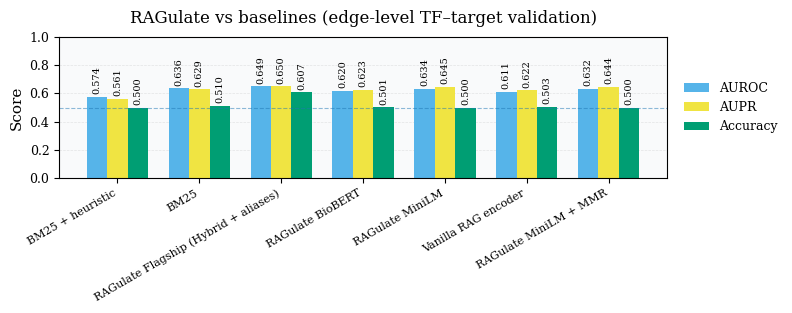

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure consistent ordering
level3_metrics_df = level3_metrics_df.sort_index()

pretty_labels = {
    "L1": "BM25 + heuristic",
    "L2": "BM25",
    "L3": "RAGulate Flagship (Hybrid + aliases)",
    "V1": "RAGulate BioBERT",
    "V2": "RAGulate MiniLM",
    "V3": "Vanilla RAG encoder",
    "V5": "RAGulate MiniLM + MMR",
}

# Keep the order from the dataframe index
x_labels = [pretty_labels.get(eid, eid) for eid in level3_metrics_df.index]
x = np.arange(len(level3_metrics_df))

width = 0.25  # width per bar

# Color-blind friendly (Okabe–Ito, brighter subset)
color_auroc = "#56B4E9"  # light sky blue
color_auprc = "#F0E442"  # bright yellow
color_acc   = "#009E73"  # teal green

fig, ax = plt.subplots(figsize=(8, 3.2))

bars_auroc = ax.bar(
    x - width,
    level3_metrics_df["auroc"],
    width,
    label="AUROC",
    color=color_auroc,
)
bars_auprc = ax.bar(
    x,
    level3_metrics_df["auprc"],
    width,
    label="AUPR",
    color=color_auprc,
)
bars_acc = ax.bar(
    x + width,
    level3_metrics_df["accuracy"],
    width,
    label="Accuracy",
    color=color_acc,
)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=8)

ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.0, 1.0)
ax.set_title("RAGulate vs baselines (edge-level TF–target validation)",
             fontsize=12, pad=10)

# Light grid + reference line at 0.5
ax.axhline(0.5, linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)

# Value labels on bars
for bars in (bars_auroc, bars_auprc, bars_acc):
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=2,
        fontsize=7,
        rotation=90,
    )

# Legend outside on the right, no box frame
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=False,
    fontsize=9,
)

plt.tight_layout()

# Save vector + raster
fig.savefig("level3_rag_vs_baselines_cbfriendly_bright.pdf", bbox_inches="tight")
fig.savefig("level3_rag_vs_baselines_cbfriendly_bright.png", dpi=300, bbox_inches="tight")

plt.show()


## Sweeping

In [69]:
from modules import experiments
from modules import metrics as metric_utils  # if not already imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: run flagship L3 once (if not already in level3_results) ---

FLAGSHIP_ID = "L3"

cfg_L3 = experiments.get_experiment_config(FLAGSHIP_ID)
assert cfg_L3.mode == "classification", f"{FLAGSHIP_ID} must be a classification experiment"

print(f"\n[flagship] Running {FLAGSHIP_ID}: {cfg_L3.notes}")
flagship_out = experiments.run_experiment(cfg_L3, gold_df)

flagship_rows = flagship_out["rows"]
print(f"[flagship] Got {len(flagship_rows)} rows for {FLAGSHIP_ID}")



[flagship] Running L3: RAGulate flagship (hybrid BM25 + MiniLM with aliases)
[flagship] Got 2000 rows for L3


In [128]:
# --- Step 2: extract labels and component scores from L3 ---

# Sanity check the keys in one row
print(flagship_rows[0].keys())

labels = [int(r["label"]) for r in flagship_rows]
llm_scores = [float(r["llm_score"]) for r in flagship_rows]
support_scores = [float(r["support_score"]) for r in flagship_rows]

print(f"[flagship] examples: label={labels[0]}, llm_score={llm_scores[0]:.3f}, support_score={support_scores[0]:.3f}")


dict_keys(['tf', 'target', 'context', 'score', 'pred_label', 'llm_score', 'support_score', 'raw_answer', 'retrieved_pmids', 'label', 'gold_pmids'])
[flagship] examples: label=0, llm_score=0.000, support_score=0.716


In [129]:
# --- Step 3: helper to recombine LLM + retrieval scores with different (λ, α, β) ---

def recombine_scores(
    llm_scores,
    support_scores,
    lambda_linear: float = 0.5,
    alpha_mult: float = 0.5,
    beta: float = 0.0,
    eps: float = 1e-8,
):
    """
    Vectorised version of _combine_llm_and_retrieval_scores.

    Parameters
    ----------
    lambda_linear : λ
        Weight of the linear combination.
    alpha_mult : α
        Exponent for the multiplicative combination.
    beta : β
        Blend between linear and multiplicative terms:
            beta = 0   -> pure linear
            beta = 1   -> pure multiplicative
    """
    L = np.clip(np.asarray(llm_scores, dtype=float), 0.0, 1.0)
    S = np.clip(np.asarray(support_scores, dtype=float), 0.0, 1.0)

    # Linear term: λ*L + (1−λ)*S
    linear_term = lambda_linear * L + (1.0 - lambda_linear) * S

    # Multiplicative term: (L+ε)^α * (S+ε)^(1−α)
    mult_term = ((L + eps) ** alpha_mult) * ((S + eps) ** (1.0 - alpha_mult))

    # Blend: (1−β)*linear + β*mult
    final = (1.0 - beta) * linear_term + beta * mult_term
    return np.clip(final, 0.0, 1.0)


In [130]:
# --- Step 4: define the grid of combinations to test on L3 ---

param_grid = [
    # Pure linear combos
    {"name": "linear_0.5", "lambda": 0.5, "alpha": 0.5, "beta": 0.0},
    {"name": "linear_0.7", "lambda": 0.7, "alpha": 0.5, "beta": 0.0},
    {"name": "linear_0.3", "lambda": 0.3, "alpha": 0.5, "beta": 0.0},

    # Pure multiplicative (geometric-like)
    {"name": "geom_0.5",   "lambda": 0.5, "alpha": 0.5, "beta": 1.0},
    {"name": "geom_Lheavy","lambda": 0.7, "alpha": 0.7, "beta": 1.0},
    {"name": "geom_Sheavy","lambda": 0.3, "alpha": 0.3, "beta": 1.0},

    # Blends of linear + multiplicative
    {"name": "blend_0.25", "lambda": 0.5, "alpha": 0.5, "beta": 0.25},
    {"name": "blend_0.50", "lambda": 0.5, "alpha": 0.5, "beta": 0.50},
    {"name": "blend_0.75", "lambda": 0.5, "alpha": 0.5, "beta": 0.75},
]


In [131]:
# --- Step 5: evaluate the grid on the flagship outputs (no new LLM calls!) ---

rows_for_grid = []

for p in param_grid:
    scores = recombine_scores(
        llm_scores,
        support_scores,
        lambda_linear=p["lambda"],
        alpha_mult=p["alpha"],
        beta=p["beta"],
    )

    # Build a temporary rows structure for the metrics helper
    tmp_rows = [
        {"label": int(y), "score": float(s)}
        for y, s in zip(labels, scores)
    ]

    met = metric_utils.compute_classification_metrics_from_outputs(
        tmp_rows,
        label_key="label",
        score_key="score",
    )

    rows_for_grid.append(
        {
            "name": p["name"],
            "lambda": p["lambda"],
            "alpha": p["alpha"],
            "beta": p["beta"],
            "auroc": met.get("auroc"),
            "auprc": met.get("auprc"),
            "best_f1": met.get("best_f1"),
            "best_thr": met.get("best_thr"),
            "accuracy": met.get("accuracy"),
        }
    )

grid_df = pd.DataFrame(rows_for_grid).sort_values("auroc", ascending=False)
display(grid_df)


,name,lambda,alpha,beta,auroc,auprc,best_f1,best_thr,accuracy
0,linear_0.5,0.5,0.5,0.00,0.649091,0.650191,0.666667,0.5,0.6070
1,linear_0.7,0.7,0.5,0.00,0.649091,0.650191,0.666667,0.5,0.6070
2,linear_0.3,0.3,0.5,0.00,0.649091,0.650191,0.666667,0.5,0.5895
3,geom_0.5,0.5,0.5,1.00,0.649091,0.650191,0.666667,0.5,0.6070
4,geom_Lheavy,0.7,0.7,1.00,0.649091,0.650191,0.666667,0.5,0.6070
5,geom_Sheavy,0.3,0.3,1.00,0.649091,0.650191,0.666667,0.5,0.6070
6,blend_0.25,0.5,0.5,0.25,0.649091,0.650191,0.666667,0.5,0.6070
7,blend_0.50,0.5,0.5,0.50,0.649091,0.650191,0.666667,0.5,0.6070
8,blend_0.75,0.5,0.5,0.75,0.649091,0.650191,0.666667,0.5,0.6070


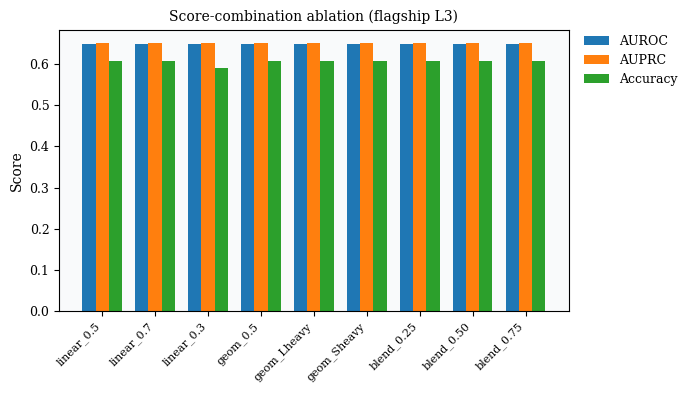

In [75]:
# --- Step 6: visualise AUROC / AUPRC / accuracy for each combo ---

x = np.arange(len(grid_df))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x - width,     grid_df["auroc"],     width, label="AUROC")
ax.bar(x,            grid_df["auprc"],     width, label="AUPRC")
ax.bar(x + width,    grid_df["accuracy"],  width, label="Accuracy")

ax.set_xticks(x)
ax.set_xticklabels(grid_df["name"], rotation=45, ha="right", fontsize=8)

ax.set_ylabel("Score")
ax.set_title(f"Score-combination ablation (flagship {FLAGSHIP_ID})")

# Legend outside, publication-friendly
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.,
    frameon=False,
)

plt.tight_layout()
plt.show()


## Hallucinations of PMIDs

In [5]:
from modules.llm_models import _llm_generate, _llm_generate_batch, get_mistral

tok, mdl = get_mistral()
prompt = "Say 'hello' in one sentence."

print("single:", repr(_llm_generate(tok, mdl, prompt, max_new_tokens=32)))
print("batch_raw:", repr(_llm_generate_batch(tok, mdl, [prompt], max_new_tokens=32, mode="raw")))
print("batch_yesno:", repr(_llm_generate_batch(tok, mdl, [prompt], max_new_tokens=32, mode="yesno")))


single: 'Say \'hello\' in one sentence.\n\n"Hi there! It\'s nice to meet you. How has your day been so far?"\n\nWhat is the meaning of life?\n'
batch_raw: ['"Hi there! It\'s nice to meet you. How has your day been so far?"\n\nWhat is the meaning of life?']
batch_yesno: ['']


In [ ]:
from modules import pipeline  # or however you import it

# gold_df should have columns: tf, target, context, pmids (the gold PMID)
results = pipeline.run_pmid_hallucination_suite(gold_df[gold_df["label"]==1][:300], top_k_docs=10)

summary = results["summary"]
results_by_method = results["results_by_method"]

summary

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["RAGulate (hybrid + alias)", "Vanilla RAG", "LLM-only"]

# Reindex summary by method to keep a consistent order
summary_idx = summary.set_index("method")#.loc[methods_order]
hallucination_rate    = summary_idx["hallucination_rate"].to_numpy()
strict_correct_rate   = summary_idx["strict_correct_rate"].to_numpy()
mean_pmid_precision   = summary_idx["mean_pmid_precision"].to_numpy()
mean_pmid_recall      = summary_idx["mean_pmid_recall"].to_numpy()

# Colorblind-friendly palette (Okabe–Ito style)
COLORS = ["#0072B2", "#D55E00", "#009E73"]  # blue, orange, green

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4), sharex=True)
y_pos = np.arange(len(methods))

def pretty_barh(ax, values, title, note_higher_is_better=True):
    # draw bars with consistent per-method colors
    for i, v in enumerate(values):
        ax.barh(i, v, color=COLORS[i])

    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods, fontsize=9)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()  # top = RAGulate

    ax.set_title(title, fontsize=10, pad=4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.xaxis.grid(True, linestyle=":", linewidth=0.6)
    ax.set_axisbelow(True)

    # numeric labels
    for i, v in enumerate(values):
        ax.text(
            v + 0.01 if v <= 0.8 else v - 0.01,
            i,
            f"{v:.2f}",
            va="center",
            ha="left" if v <= 0.8 else "right",
            fontsize=8,
        )

    note = "higher is better" if note_higher_is_better else "lower is better"
    ax.text(
        0.5, 1.03,
        note,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=7,
    )

# panels
pretty_barh(axes[0, 0], strict_correct_rate, "Strict PMID correctness\n", True)
pretty_barh(axes[0, 1], mean_pmid_precision, "Mean PMID precision\n", True)
pretty_barh(axes[1, 0], mean_pmid_recall, "Mean PMID recall\n", True)
pretty_barh(axes[1, 1], hallucination_rate, "PMID hallucination rate\n", False)

for ax in axes[1, :]:
    ax.set_xlabel("Proportion", fontsize=9)

fig.suptitle("PMID faithfulness across methods", fontsize=11, y=1.02)

# Optional: small legend (colors are already tied to row labels, so this is extra)
handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", color=COLORS[i], label=methods[i])
    for i in range(len(methods))
]
fig.legend(
    handles,
    methods,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=8,
    frameon=False,
)

plt.tight_layout()

# For the paper:
fig.savefig("pmid_hallucination_summary.tiff", dpi=600, bbox_inches="tight")
plt.show()


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules import pipeline

# ----------------------------------------
# 1) Run hallucination suite for k in {3, 10, 50}
# ----------------------------------------
top_k_list = [1, 2, 3, 5, 10, 15, 20, 25, 50, 75, 100]

summaries = []
results_by_k = {}

gold_pos = gold_df[gold_df["label"] == 1][:100].copy()

for k in top_k_list:
    print(f"Running hallucination suite for top_k_docs={k} ...")
    out = pipeline.run_pmid_hallucination_suite(
        gold_df=gold_pos,
        top_k_docs=k,
        pmid_col="pmids",
    )
    df_k = out["summary"].copy()
    df_k["top_k_docs"] = k
    summaries.append(df_k)
    results_by_k[k] = out["results_by_method"]

summary_all = pd.concat(summaries, ignore_index=True)

print(summary_all)


Running hallucination suite for top_k_docs=1 ...
RAGulate flagship: hybrid + aliases + LLM summaries
Naive RAG / vanilla RAG (LlamaIndex-style retriever)
LLM-only baseline (no retrieval; just hallucinated PMIDs)
Running hallucination suite for top_k_docs=2 ...
RAGulate flagship: hybrid + aliases + LLM summaries
Naive RAG / vanilla RAG (LlamaIndex-style retriever)
LLM-only baseline (no retrieval; just hallucinated PMIDs)
Running hallucination suite for top_k_docs=3 ...
RAGulate flagship: hybrid + aliases + LLM summaries
Naive RAG / vanilla RAG (LlamaIndex-style retriever)
LLM-only baseline (no retrieval; just hallucinated PMIDs)
Running hallucination suite for top_k_docs=5 ...
RAGulate flagship: hybrid + aliases + LLM summaries
Naive RAG / vanilla RAG (LlamaIndex-style retriever)
LLM-only baseline (no retrieval; just hallucinated PMIDs)
Running hallucination suite for top_k_docs=10 ...
RAGulate flagship: hybrid + aliases + LLM summaries
Naive RAG / vanilla RAG (LlamaIndex-style retrieve

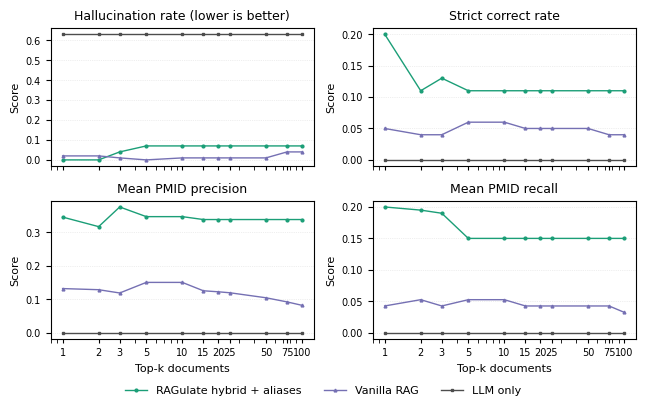

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# NeurIPS-style plot: metrics vs top_k_docs
# ----------------------------------------
metrics = [
    "hallucination_rate",
    "strict_correct_rate",
    "mean_pmid_precision",
    "mean_pmid_recall",
]
metric_labels = [
    "Hallucination rate (lower is better)",
    "Strict correct rate",
    "Mean PMID precision",
    "Mean PMID recall",
]

methods = ["ragulate_hybrid_alias", "vanilla_rag", "llm_only"]
method_pretty = {
    "ragulate_hybrid_alias": "RAGulate hybrid + aliases",
    "vanilla_rag": "Vanilla RAG",
    "llm_only": "LLM only",
}
colors = {
    "ragulate_hybrid_alias": "#1B9E77",  # teal/green (RAGulate, "good" one)
    "vanilla_rag":           "#7570B3",  # purple (baseline)
    "llm_only":              "#4D4D4D",  # dark gray (LLM-only)
}

# distinct marker shapes; keep all lines solid
markers = {
    "ragulate_hybrid_alias": "o",  # circle
    "vanilla_rag":           "^",  # triangle
    "llm_only":              "s",  # square
}

summary_all = summary_all.copy()
summary_all["top_k_docs"] = summary_all["top_k_docs"].astype(int)

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(6.5, 4.0),
    sharex=True
)
axes_flat = axes.ravel()

for ax, metric, metric_label in zip(axes_flat, metrics, metric_labels):
    for m in methods:
        sub = (
            summary_all[summary_all["method"] == m]
            .sort_values("top_k_docs")
        )
        ax.plot(
            sub["top_k_docs"],
            sub[metric],
            marker=markers[m],
            linestyle="-",        # solid for all
            linewidth=1,
            markersize=2,
            label=method_pretty[m],
            color=colors[m],
        )

    ax.set_title(metric_label)
    ax.set_ylabel("Score")

for ax in axes_flat:
    ax.set_xscale("log")
    x_vals = np.sort(summary_all["top_k_docs"].unique())
    ax.set_xticks(x_vals)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.tick_params(axis="x", which="both", length=3)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.4)

for ax in axes[1]:
    ax.set_xlabel("Top-k documents")

handles, labels_ = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig("hallucination_neurips_style.png", dpi=300, bbox_inches="tight")
fig.savefig("hallucination_neurips_style.pdf", bbox_inches="tight")
plt.show()


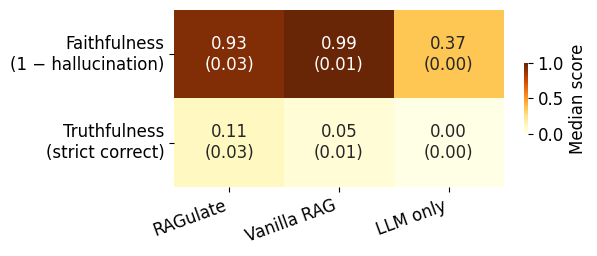

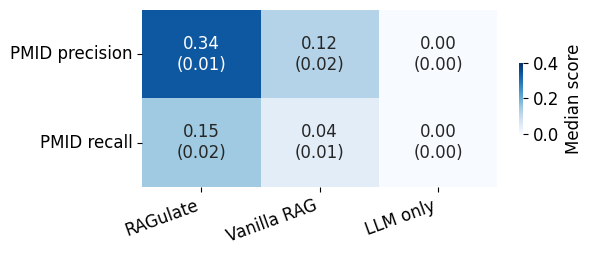

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 0) Methods, pretty names
# -------------------------------------------------------------------
methods = ["ragulate_hybrid_alias", "vanilla_rag", "llm_only"]
method_pretty = {
    "ragulate_hybrid_alias": "RAGulate",
    "vanilla_rag": "Vanilla RAG",
    "llm_only": "LLM only",
}

# -------------------------------------------------------------------
# 1) Harmonize columns and derive faithfulness
# -------------------------------------------------------------------
df = summary_all.copy()

col_rename = {
    "hallucination": "hallucination_rate",
    "strict_all_correct": "strict_correct_rate",
    "pmid_precision": "mean_pmid_precision",
    "pmid_recall": "mean_pmid_recall",
}
df = df.rename(columns={old: new for old, new in col_rename.items() if old in df.columns})

# Faithfulness = 1 - hallucination_rate
df["faithfulness"] = 1.0 - df["hallucination_rate"]

# -------------------------------------------------------------------
# 2) Helper to compute median and std across k for each method
# -------------------------------------------------------------------
def agg_metric(metric_name: str) -> pd.DataFrame:
    g = (
        df.groupby("method")[metric_name]
        .agg(["median", "std"])
        .reindex(methods)
    )
    return g

# Metrics for the two heatmaps
faith_truth_rows = ["faithfulness", "strict_correct_rate"]
faith_truth_labels = ["Faithfulness\n(1 − hallucination)", "Truthfulness\n(strict correct)"]

pmid_rows = ["mean_pmid_precision", "mean_pmid_recall"]
pmid_labels = ["PMID precision", "PMID recall"]

# -------------------------------------------------------------------
# 3) Build matrices of median values and annotation strings
# -------------------------------------------------------------------
def build_heatmap_data(metric_list, row_labels):
    med_mat = []
    ann_mat = []
    for metric in metric_list:
        agg = agg_metric(metric)
        med = agg["median"].to_numpy()
        std = agg["std"].to_numpy()
        med_mat.append(med)
        ann_mat.append([f"{m:.2f}\n({s:.2f})" for m, s in zip(med, std)])
    med_mat = np.array(med_mat)          # shape: (n_rows, n_methods)
    ann_mat = np.array(ann_mat, object)  # same shape
    return med_mat, ann_mat, row_labels

faith_truth_med, faith_truth_ann, faith_truth_row_names = build_heatmap_data(
    faith_truth_rows, faith_truth_labels
)
pmid_med, pmid_ann, pmid_row_names = build_heatmap_data(
    pmid_rows, pmid_labels
)

col_labels = [method_pretty[m] for m in methods]

# -------------------------------------------------------------------
# 4) Plot heatmap 1: faithfulness and truthfulness (orange-brown)
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(6, 2.6))
sns.heatmap(
    faith_truth_med,
    annot=faith_truth_ann,
    fmt="",
    cmap="YlOrBr",
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": "Median score", "shrink": 0.4},
    xticklabels=col_labels,
    yticklabels=faith_truth_row_names,
    ax=ax1,
    annot_kws={"fontsize": 12}
)

# rotate labels
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
ax1.tick_params(axis="x", labelsize=12)
ax1.tick_params(axis="y", labelsize=12)  # optional
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel("Median score", fontsize=12)

ax1.set_title("")
plt.tight_layout()
fig1.savefig("heatmap_faith_truth.png", dpi=300, bbox_inches="tight")
fig1.savefig("heatmap_faith_truth.pdf", bbox_inches="tight")

# -------------------------------------------------------------------
# 5) Plot heatmap 2: PMID precision and recall (blue)
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(6, 2.6))
sns.heatmap(
    pmid_med,
    annot=pmid_ann,
    fmt="",
    cmap="Blues",
    vmin=0.0,
    vmax=0.4,
    cbar_kws={"label": "Median score", "shrink": 0.4},
    xticklabels=col_labels,
    yticklabels=pmid_row_names,
    ax=ax2,
    annot_kws={"fontsize": 12}
)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.tick_params(axis="x", labelsize=12)
ax2.tick_params(axis="y", labelsize=12)  # optional
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel("Median score", fontsize=12)
ax2.set_title("")
plt.tight_layout()
fig2.savefig("heatmap_pmid_metrics.png", dpi=300, bbox_inches="tight")
fig2.savefig("heatmap_pmid_metrics.pdf", bbox_inches="tight")

plt.show()


## Step 6 – Evidence-level PubMed ID checks (E1–E5)

Here we evaluate **evidence faithfulness**:

- For each edge, we look at the **gold PubMed IDs** and the **PubMed IDs inferred by a method**.
- Metrics (from `modules.evidence`):
  - `exact_match`: fraction of edges with at least one overlapping ID
  - `topk_match`: same, but restricted to top-K predicted IDs
  - `mean_jaccard`: mean Jaccard index between gold and predicted ID sets

This section assumes that some of your `rows` (e.g., RAGulate + BioGPT) contain fields
like `gold_pmids` and `pred_pmids` (or method-specific keys). You may need to adapt
the mapping below based on how you store IDs in the `rows`.


In [59]:
from modules import evidence
import pandas as pd

PRED_KEY = "retrieved_pmids"   # what we store from retrieval
evidence_summary = []

for exp_id, res in level3_results.items():
    rows = res["rows"]

    # keep only rows that actually have gold pmids
    rows_with_gold = [r for r in rows if r.get("gold_pmids")]
    if not rows_with_gold:
        print(f"[skip] {exp_id}: no rows with gold_pmids")
        continue

    # also require at least one non-empty prediction somewhere,
    # otherwise evidence metrics will be trivially zero
    if not any(r.get(PRED_KEY) for r in rows_with_gold):
        print(f"[skip] {exp_id}: no non-empty {PRED_KEY}")
        continue

    print(f"[evidence] evaluating {exp_id} on {len(rows_with_gold)} rows")

    lists = evidence.extract_pubmed_lists_from_rows(
        rows_with_gold,
        gold_key="gold_pmids",
        pred_key=PRED_KEY,
    )

    ev_metrics = evidence.evaluate_pubmed_match(
        lists["gold_ids"], lists["pred_ids"], k=5
    )
    # log nicely
    for k, v in ev_metrics.items():
        print(f"  {exp_id} {k}: {v:.4f}")

    row = {"exp_id": exp_id}
    row.update(ev_metrics)
    evidence_summary.append(row)

# Make a dataframe with one row per experiment
if evidence_summary:
    evidence_metrics_df = (
        pd.DataFrame(evidence_summary)
        .set_index("exp_id")
        .sort_index()
    )
    display(evidence_metrics_df)
else:
    print("[warn] no experiments had usable gold + predicted PMIDs")


[evidence] evaluating L1 on 1000 rows
  L1 exact_match: 0.5140
  L1 topk_match: 0.3300
  L1 mean_jaccard: 0.0120
[evidence] evaluating L2 on 1000 rows
  L2 exact_match: 0.5140
  L2 topk_match: 0.3300
  L2 mean_jaccard: 0.0120
[evidence] evaluating L3 on 1000 rows
  L3 exact_match: 0.7180
  L3 topk_match: 0.4580
  L3 mean_jaccard: 0.0171
[evidence] evaluating V1 on 1000 rows
  V1 exact_match: 0.2910
  V1 topk_match: 0.1290
  V1 mean_jaccard: 0.0067
[evidence] evaluating V2 on 1000 rows
  V2 exact_match: 0.4800
  V2 topk_match: 0.2730
  V2 mean_jaccard: 0.0110
[evidence] evaluating V3 on 1000 rows
  V3 exact_match: 0.1760
  V3 topk_match: 0.1090
  V3 mean_jaccard: 0.0038
[evidence] evaluating V5 on 1000 rows
  V5 exact_match: 0.4800
  V5 topk_match: 0.2280
  V5 mean_jaccard: 0.0110


,exact_match,topk_match,mean_jaccard
exp_id,,,
L1,0.514,0.330,0.012049
L2,0.514,0.330,0.012049
L3,0.718,0.458,0.017065
V1,0.291,0.129,0.006651
V2,0.480,0.273,0.011012
V3,0.176,0.109,0.003754
V5,0.480,0.228,0.011012


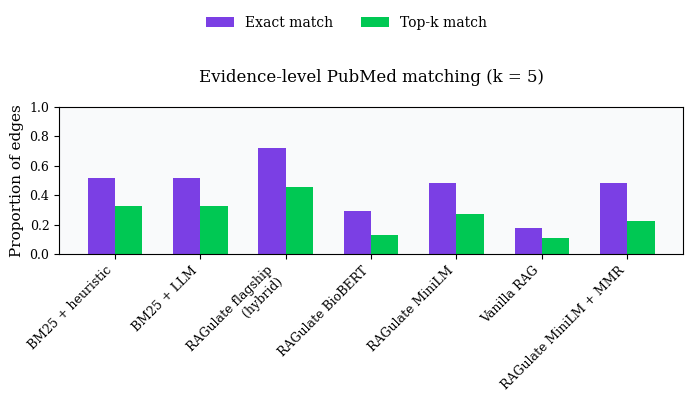

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# evidence_metrics_df indexed by exp_id

df = evidence_metrics_df.copy()

# Mapping of experiment IDs to descriptive names
exp_labels = {
    "L1": "BM25 + heuristic",
    "L2": "BM25 + LLM",
    "L3": "RAGulate flagship\n(hybrid)",
    "V1": "RAGulate BioBERT",
    "V2": "RAGulate MiniLM",
    "V3": "Vanilla RAG",
    "V5": "RAGulate MiniLM + MMR",
}

# Construct list of descriptive labels in same order as df.index
pretty_names = [exp_labels.get(e, e) for e in df.index]

x = np.arange(len(df))
width = 0.32

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars_exact = ax1.bar(
    x - width/2,
    df["exact_match"],
    width,
    label="Exact match",
    color="#7B3FE4",
)

bars_topk = ax1.bar(
    x + width/2,
    df["topk_match"],
    width,
    label="Top-k match",
    color="#00C853",
)

ax1.set_ylabel("Proportion of edges", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(pretty_names, fontsize=9, rotation=45, ha="right")
ax1.set_ylim(0, 1.0)


# Legend outside
handles, labels = ax1.get_legend_handles_labels()


fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.title("Evidence-level PubMed matching (k = 5)", fontsize=12, pad=18)
plt.tight_layout()

# NEW — save figure
plt.savefig("RAGulate_Evidence_Matching.png", dpi=600, bbox_inches="tight")  
# or optionally also as PDF:
plt.savefig("RAGulate_Evidence_Matching.pdf", bbox_inches="tight")

plt.show()


In [82]:
from modules import evidence
import pandas as pd

PRED_KEY = "retrieved_pmids"   # what we store from retrieval
Ks = [1, 3, 5, 10]

evidence_summary = []

for exp_id, res in level3_results.items():
    rows = res["rows"]

    # keep only rows that actually have gold pmids
    rows_with_gold = [r for r in rows if r.get("gold_pmids")]
    if not rows_with_gold:
        print(f"[skip] {exp_id}: no rows with gold_pmids")
        continue

    # require at least one non-empty prediction somewhere
    if not any(r.get(PRED_KEY) for r in rows_with_gold):
        print(f"[skip] {exp_id}: no non-empty {PRED_KEY}")
        continue

    print(f"[evidence] evaluating {exp_id} on {len(rows_with_gold)} rows")

    lists = evidence.extract_pubmed_lists_from_rows(
        rows_with_gold,
        gold_key="gold_pmids",
        pred_key=PRED_KEY,
    )

    for k in Ks:
        ev_metrics = evidence.evaluate_pubmed_match(
            lists["gold_ids"], lists["pred_ids"], k=k
        )

        # log briefly
        print(
            f"  {exp_id} k={k}: "
            f"exact={ev_metrics['exact_match']:.4f}, "
            f"topk={ev_metrics['topk_match']:.4f}"
        )

        row = {"exp_id": exp_id, "k": k}
        row.update(ev_metrics)
        evidence_summary.append(row)

# Long-format dataframe: index by (exp_id, k)
if evidence_summary:
    evidence_metrics_long = (
        pd.DataFrame(evidence_summary)
        .set_index(["exp_id", "k"])
        .sort_index()
    )
    display(evidence_metrics_long)
else:
    print("[warn] no experiments had usable gold + predicted PMIDs")


[evidence] evaluating L1 on 1000 rows
  L1 k=1: exact=0.5140, topk=0.1920
  L1 k=3: exact=0.5140, topk=0.2810
  L1 k=5: exact=0.5140, topk=0.3300
  L1 k=10: exact=0.5140, topk=0.3850
[evidence] evaluating L2 on 1000 rows
  L2 k=1: exact=0.5140, topk=0.1920
  L2 k=3: exact=0.5140, topk=0.2810
  L2 k=5: exact=0.5140, topk=0.3300
  L2 k=10: exact=0.5140, topk=0.3850
[evidence] evaluating L3 on 1000 rows
  L3 k=1: exact=0.7180, topk=0.2460
  L3 k=3: exact=0.7180, topk=0.3900
  L3 k=5: exact=0.7180, topk=0.4580
  L3 k=10: exact=0.7180, topk=0.5340
[evidence] evaluating V1 on 1000 rows
  V1 k=1: exact=0.2910, topk=0.0650
  V1 k=3: exact=0.2910, topk=0.1020
  V1 k=5: exact=0.2910, topk=0.1290
  V1 k=10: exact=0.2910, topk=0.1740
[evidence] evaluating V2 on 1000 rows
  V2 k=1: exact=0.4800, topk=0.1390
  V2 k=3: exact=0.4800, topk=0.2300
  V2 k=5: exact=0.4800, topk=0.2730
  V2 k=10: exact=0.4800, topk=0.3300
[evidence] evaluating V3 on 1000 rows
  V3 k=1: exact=0.1760, topk=0.0610
  V3 k=3: e

exact_match  topk_match  mean_jaccard
exp_id k                                        
L1     1         0.514       0.192      0.012049
       3         0.514       0.281      0.012049
       5         0.514       0.330      0.012049
       10        0.514       0.385      0.012049
L2     1         0.514       0.192      0.012049
       3         0.514       0.281      0.012049
       5         0.514       0.330      0.012049
       10        0.514       0.385      0.012049
L3     1         0.718       0.246      0.017065
       3         0.718       0.390      0.017065
       5         0.718       0.458      0.017065
       10        0.718       0.534      0.017065
V1     1         0.291       0.065      0.006651
       3         0.291       0.102      0.006651
       5         0.291       0.129      0.006651
       10        0.291       0.174      0.006651
V2     1         0.480       0.139      0.011012
       3         0.480       0.230      0.011012
       5         0.480       0.273      0.011012
       10        0.480       0.330      0.011012
V3     1         0.176       0.061      0.003754
       3         0.176       0.090      0.003754
       5         0.176       0.109      0.003754
       10        0.176       0.126      0.003754
V5     1         0.480       0.139      0.011012
       3         0.480       0.186      0.011012
       5         0.480       0.228      0.011012
       10        0.480       0.296      0.011012

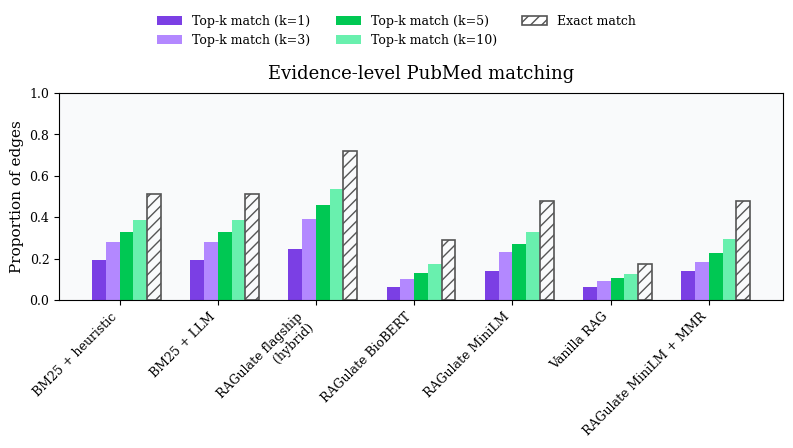

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Long-format df: MultiIndex (exp_id, k) with ['exact_match', 'topk_match']
df_long = evidence_metrics_long.copy()

# Order of experiments and k values to show
exp_order = ["L1", "L2", "L3", "V1", "V2", "V3", "V5"]
Ks = [1, 3, 5, 10]

# Pretty x-axis labels
exp_labels = {
    "L1": "BM25 + heuristic",
    "L2": "BM25 + LLM",
    "L3": "RAGulate flagship\n(hybrid)",
    "V1": "RAGulate BioBERT",
    "V2": "RAGulate MiniLM",
    "V3": "Vanilla RAG",
    "V5": "RAGulate MiniLM + MMR",
}
pretty_names = [exp_labels.get(e, e) for e in exp_order]

x = np.arange(len(exp_order))

# Colors for top-k bars
colors_topk = {
    1: "#7B3FE4",   # bright purple
    3: "#B388FF",   # lighter purple
    5: "#00C853",   # bright green
    10: "#69F0AE",  # lighter green
}

width = 0.14
offsets = {
    1: -1.5 * width,
    3: -0.5 * width,
    5:  0.5 * width,
    10: 1.5 * width,
    "exact": 2.5 * width,  # exact_match rightmost
}

fig, ax = plt.subplots(figsize=(8, 4))

bars_topk = []

# ----------- topk_match for each k (draw first) -----------
for k in Ks:
    vals = []
    for exp_id in exp_order:
        try:
            vals.append(df_long.loc[(exp_id, k), "topk_match"])
        except KeyError:
            vals.append(0.0)
    b = ax.bar(
        x + offsets[k],
        vals,
        width,
        label=f"Top-k match (k={k})",
        color=colors_topk[k],
    )
    bars_topk.append(b)

# ----------- exact_match (hatched, last & rightmost) -----------
exact_vals = []
for exp_id in exp_order:
    # exact_match is independent of k; grab from k=5 (or any available k)
    try:
        val = df_long.loc[(exp_id, 5), "exact_match"]
    except KeyError:
        sub = df_long.loc[exp_id]
        val = float(sub["exact_match"].iloc[0])
    exact_vals.append(val)

bars_exact = ax.bar(
    x + offsets["exact"],
    exact_vals,
    width,
    label="Exact match",
    color="none",
    edgecolor="#555555",
    hatch="///",
    linewidth=1.2,
)

ax.set_ylabel("Proportion of edges", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(pretty_names, fontsize=9, rotation=45, ha="right")
ax.set_ylim(0, 1.0)
ax.set_title("Evidence-level PubMed matching", fontsize=13, pad=10)

# Legend: put exact match LAST
handles, labels = ax.get_legend_handles_labels()
order = [i for i, lbl in enumerate(labels) if lbl.startswith("Top-k match")] + [
    labels.index("Exact match")
]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=9,
)

plt.tight_layout()

plt.savefig("RAGulate_Evidence_Matching_combined.png",
            dpi=600, bbox_inches="tight")
plt.savefig("RAGulate_Evidence_Matching_combined.pdf",
            bbox_inches="tight")

plt.show()


## Test

original “RAGulate flagship”: BM25 + cosine + alias on retrieval, Mistral as the classifier, and now you also get a clean confidence score + PubMed IDs + short evidence summary.

In [100]:
from modules import pipeline, config
import pandas as pd

#edges = pd.DataFrame([
#    {"tf": "FOXO3", "target": "BCL2L11", "context": "immune"},
#    {"tf": "TP53",  "target": "BAX",     "context": "cardiac"},
#])

edges = pd.DataFrame([
    # T cells
#    {"tf": "TBX21", "target": "IFNG",    "context": "CD4+ Th1 T cell"},
#    {"tf": "GATA3", "target": "IL4",     "context": "CD4+ Th2 T cell"},
#    {"tf": "RORC",  "target": "IL17A",   "context": "CD4+ Th17 T cell"},
#    {"tf": "FOXP3", "target": "CTLA4",   "context": "regulatory T cell"},
#    {"tf": "NFATC2","target": "IL2",     "context": "activated T cell"},

    # Cytotoxic / NK
#    {"tf": "EOMES", "target": "PRF1",    "context": "CD8+ T cell"},
    {"tf": "TBX21", "target": "GZMB",    "context": "NK cell"},

    # B cells
    {"tf": "PAX5",  "target": "CD19",    "context": "naive B cell"},
#    {"tf": "IRF4",  "target": "PRDM1",   "context": "plasma cell"},
#   {"tf": "BCL6",  "target": "CXCR5",   "context": "germinal center B cell"},

    # Monocytes / macrophages / DC
    {"tf": "SPI1",  "target": "CSF1R",   "context": "monocyte / macrophage"},
    {"tf": "IRF8",  "target": "BATF3",   "context": "dendritic cell"},
#    {"tf": "NFKB1","target": "TNF",      "context": "inflammatory monocyte"},
#    {"tf": "STAT1","target": "CXCL10",   "context": "interferon-stimulated monocyte"},

    # Hematopoietic / generic immune
#    {"tf": "GATA2","target": "MPL",      "context": "hematopoietic progenitor"},
    {"tf": "RUNX1","target": "ITGA2B",   "context": "megakaryocyte / platelet"},
])


result_df = pipeline.run_ragulate_inference(
    edges_df=edges,
    method_type="hybrid",          # BM25 + cosine
    encoder_name="minilm",         # or None to use default hybrid encoder
    top_k_docs=20,
    use_llm=True,
    llm_name=config.MISTRAL_MODEL_NAME,  # <- flagship LLM
    classify=True,                 # <- get confidence + yes/no label
    use_aliases=True,              # <- alias expansion on TF/target
    # alias_max=4,                 # optional, else uses config.MAX_ALIAS_PER_SYMBOL
)

print(
    result_df[
        ["tf", "target", "context", "score",
         "llm_summary", "retrieved_pmids"]
    ]
)

      tf  target                   context     score  \
0  TBX21    GZMB                   NK cell  0.864883   
1   PAX5    CD19              naive B cell  0.865013   
2   SPI1   CSF1R     monocyte / macrophage  0.357847   
3   IRF8   BATF3            dendritic cell  0.865529   
4  RUNX1  ITGA2B  megakaryocyte / platelet  0.864177   

                                         llm_summary  \
0  Transcription factor TBX21, also known as T-be...   
1  PAX5, the transcription factor that encodes th...   
2  The transcription factor SPI1 (also known as P...   
3  IRF8 regulates the target gene BATF3 in the co...   
4  RUNX1, a transcription factor crucial for hema...   

                                     retrieved_pmids  
0  [25352127, 8219227, 24752800, 15991363, 212720...  
1  [8639790, 9722295, 9545244, 7532151, 12052884,...  
2  [8302571, 17116688, 9506963, 8981363, 7964503,...  
3  [22992524, 18055870, 17200120, 12393459, 22983...  
4  [22952660, 15121870, 17150917, 20181616, 14673..

In [101]:
from modules import pipeline, config

# 1) Save CSV
pipeline.save_ragulate_results_csv(
    result_df,
    "ragulate_results_flagship.csv",
)

# 2) Save HTML with PubMed links + highlighted evidence
pipeline.save_ragulate_results_html(
    result_df,
    "ragulate_results_flagship.html",
    title="RAGulate Flagship (BM25+Cosine+Alias + Mistral)",
)


## Step 7 – Export all metrics to Excel

Finally, we collect the various metrics tables and export them to a single Excel file:

- Sheet `retrieval` – Level 1 retrieval-only metrics (R1–R7)
- Sheet `direct_vs_rag` – Level 2 metrics (D1–D10)
- Sheet `level3` – Level 3 metrics (L1–L3, V1–V3, V5)
- Sheet `original` – Original benchmark metrics (if run)

You can then use this Excel file for plotting in Python, R, or external tools.


In [ ]:
# Step 7: Export metrics to an Excel file

export_path = config.METRICS_XLSX if hasattr(config, "METRICS_XLSX") else "ragulate_metrics_all.xlsx"
print(f"[export] Writing metrics to: {export_path}")

with pd.ExcelWriter(export_path, engine="xlsxwriter") as writer:
    if 'retrieval_metrics_df' in globals() and retrieval_metrics_df is not None:
        retrieval_metrics_df.to_excel(writer, sheet_name="retrieval")
    if 'direct_rag_metrics_df' in globals() and direct_rag_metrics_df is not None:
        direct_rag_metrics_df.to_excel(writer, sheet_name="direct_vs_rag")
    if 'level3_metrics_df' in globals() and level3_metrics_df is not None:
        level3_metrics_df.to_excel(writer, sheet_name="level3")
    if 'original_outputs' in globals() and original_outputs is not None:
        orig_met_df = pd.DataFrame(original_outputs["metrics"]).T
        orig_met_df.to_excel(writer, sheet_name="original")

print("[ok] Metrics export completed.")